Step 1 : Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

Step 2 : Load & Preprocessing Data

In [23]:
# Load dataset
df = pd.read_csv('heart.csv')

# Membersihkan nama kolom
df.columns = df.columns.str.strip()

print("5 Data Pertama:")
print(df.head())

print("\nInformasi Dataset:")
print(df.info())

5 Data Pertama:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4  

Step 3 : Handle Missing Value

In [24]:
# Menghapus missing value jika ada
df = df.dropna()

print("Jumlah data setelah cleaning:")
print(df.shape)

Jumlah data setelah cleaning:
(1025, 14)


Step 4 : Feature & Target

In [25]:
# Pisahkan fitur dan target
X_raw = df.drop('target', axis=1).astype(float).values
y_raw = df['target'].astype(float).values.reshape(-1, 1)

print("Shape X:", X_raw.shape)
print("Shape y:", y_raw.shape)

Shape X: (1025, 13)
Shape y: (1025, 1)


Step 5 : Normalisasi Data

In [26]:
# Standardisasi data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)

print("Data berhasil dinormalisasi")

Data berhasil dinormalisasi


Step 6 : Split Data Training & Testing

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print("Jumlah data training:", X_train.shape)
print("Jumlah data testing:", X_test.shape)

Jumlah data training: (820, 13)
Jumlah data testing: (205, 13)


Step 7 : Transpose Matriks untuk ANN

In [28]:
# Transpose agar sesuai format ANN
X_train_t = X_train.T
y_train_t = y_train.T

X_test_t = X_test.T
y_test_t = y_test.T

print("Dimensi Data Training:", X_train_t.shape)
print("Dimensi Target Training:", y_train_t.shape)

print("Dimensi Data Testing:", X_test_t.shape)
print("Dimensi Target Testing:", y_test_t.shape)

Dimensi Data Training: (13, 820)
Dimensi Target Training: (1, 820)
Dimensi Data Testing: (13, 205)
Dimensi Target Testing: (1, 205)


Step 8 : Define Activation Function

In [29]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

Step 9 : Initialize Parameters

In [30]:
def initialize_parameters(input_size, hidden_size, output_size):

    np.random.seed(42)

    # Hidden Layer
    W1 = np.random.randn(hidden_size, input_size) * 0.1
    b1 = np.zeros((hidden_size, 1))

    # Output Layer
    W2 = np.random.randn(output_size, hidden_size) * 0.1
    b2 = np.zeros((output_size, 1))

    return {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }

Step 10 : Forward Propagation

In [31]:
def forward_propagation(X, parameters):

    W1 = parameters["W1"]
    b1 = parameters["b1"]

    W2 = parameters["W2"]
    b2 = parameters["b2"]

    # Hidden Layer
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # Output Layer
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

Step 11 : Compute Loss

In [32]:
def compute_loss(A2, Y):

    m = Y.shape[1]

    loss = -1/m * np.sum(
        Y * np.log(A2 + 1e-15) +
        (1 - Y) * np.log(1 - A2 + 1e-15)
    )

    return loss

Step 12 : Backward Propagation

In [33]:
def backward_propagation(parameters, cache, X, Y):

    m = X.shape[1]

    W2 = parameters["W2"]

    A1 = cache["A1"]
    A2 = cache["A2"]
    Z1 = cache["Z1"]

    # Output Layer
    dZ2 = A2 - Y

    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    # Hidden Layer
    dZ1 = np.dot(W2.T, dZ2) * relu_derivative(Z1)

    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads

Step 13 : Upgrade Parameters

In [34]:
def update_parameters(parameters, grads, learning_rate):

    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]

    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]

    return parameters

Step 14 : Training the Model Neural Network

In [35]:
def train_neural_network(
    X,
    Y,
    input_size,
    hidden_size,
    output_size,
    epochs,
    learning_rate
):

    parameters = initialize_parameters(
        input_size,
        hidden_size,
        output_size
    )

    loss_history = []

    for epoch in range(epochs):

        # Forward propagation
        A2, cache = forward_propagation(X, parameters)

        # Compute loss
        loss = compute_loss(A2, Y)

        loss_history.append(loss)

        # Backward propagation
        grads = backward_propagation(
            parameters,
            cache,
            X,
            Y
        )

        # Update parameter
        parameters = update_parameters(
            parameters,
            grads,
            learning_rate
        )

        # Menampilkan loss setiap 250 epoch
        if epoch % 250 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.6f}")

    # Visualisasi loss
    plt.figure(figsize=(8,5))

    plt.plot(loss_history, linewidth=2)

    plt.title("Grafik Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.grid(alpha=0.4)

    plt.show()

    return parameters

Step 15 : Making Predictions

In [36]:
def predict(X, parameters):

    A2, _ = forward_propagation(X, parameters)

    predictions = (A2 >= 0.5).astype(int)

    return predictions, A2

Step 16 : Training Model ANN


--- PROSES TRAINING MODEL ANN ---
Epoch 0 | Loss: 0.699229
Epoch 250 | Loss: 0.367375
Epoch 500 | Loss: 0.319052
Epoch 750 | Loss: 0.299939
Epoch 1000 | Loss: 0.287018
Epoch 1250 | Loss: 0.275845
Epoch 1500 | Loss: 0.266700
Epoch 1750 | Loss: 0.256588
Epoch 2000 | Loss: 0.244902
Epoch 2250 | Loss: 0.233432
Epoch 2500 | Loss: 0.218212
Epoch 2750 | Loss: 0.203205
Epoch 3000 | Loss: 0.190583
Epoch 3250 | Loss: 0.178394
Epoch 3500 | Loss: 0.167148
Epoch 3750 | Loss: 0.158086


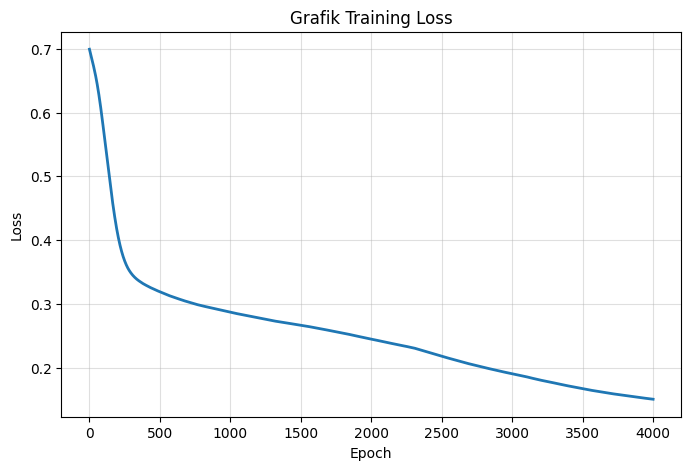

In [37]:
# Menentukan arsitektur jaringan
input_size = X_train_t.shape[0]
hidden_size = 12
output_size = 1

# Training model
print("\n--- PROSES TRAINING MODEL ANN ---")

trained_parameters = train_neural_network(
    X_train_t,
    y_train_t,
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    epochs=4000,
    learning_rate=0.05
)

Step 17 : Testing the Model

In [38]:
# Prediksi data testing
predictions_test, probabilities_test = predict(
    X_test_t,
    trained_parameters
)

# Menyesuaikan bentuk array
y_true = y_test_t.flatten()
y_pred = predictions_test.flatten()

# Menghitung akurasi
accuracy = accuracy_score(y_true, y_pred)

print("\n--- HASIL PENGUJIAN MODEL ---")

print(f"Akurasi Model: {accuracy * 100:.2f}%\n")


--- HASIL PENGUJIAN MODEL ---
Akurasi Model: 91.71%



Step 18 : Classification Report

In [39]:
print("Classification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "No Heart Disease (0)",
            "Heart Disease (1)"
        ],
        zero_division=0
    )
)

Classification Report:
                      precision    recall  f1-score   support

No Heart Disease (0)       0.91      0.92      0.92       100
   Heart Disease (1)       0.92      0.91      0.92       105

            accuracy                           0.92       205
           macro avg       0.92      0.92      0.92       205
        weighted avg       0.92      0.92      0.92       205



Step 19 : ROC AUC Score

In [40]:
auc = roc_auc_score(
    y_true,
    probabilities_test.flatten()
)

print(f"ROC AUC Score: {auc:.4f}")

ROC AUC Score: 0.9701


Step 20 : Confusion Matrix

In [41]:
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[92  8]
 [ 9 96]]


Step 21 : Visualisasi Confusion Matrix

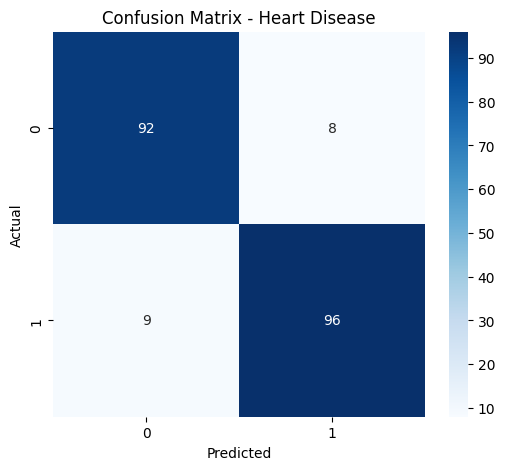

In [42]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Heart Disease")

plt.show()

# Analisis Hasil

# Analisis Hasil

Model ANN berhasil mencapai akurasi 91.71% pada data testing, artinya lebih dari 9 dari 10 prediksi benar. ROC AUC Score yang mendekati 1.0 menunjukkan model mampu membedakan pasien dengan dan tanpa penyakit jantung.

Dari confusion matrix, True Positive dan True Negative mendominasi hasil, meskipun terdapat beberapa False Negative yang perlu diperhatikan karena dalam konteks medis, pasien sakit yang diprediksi sehat adalah kesalahan paling kritis. Classification report menunjukkan precision dan recall yang seimbang untuk kedua kelas, artinya model tidak bias ke salah satu kelas.

# Kesimpulan

Model Artificial Neural Network (ANN) berhasil diterapkan untuk melakukan klasifikasi penyakit jantung menggunakan dataset Heart Disease dari Kaggle. Model memperoleh akurasi sebesar 91.71%. Hal ini menunjukkan bahwa ANN mampu mempelajari pola dari data medis pasien untuk memprediksi penyakit jantung.

Selain akurasi, evaluasi menggunakan confusion matrix, classification report, dan ROC AUC Score juga menunjukkan bahwa model memiliki performa klasifikasi yang cukup baik. Dengan demikian, metode ANN dapat digunakan sebagai salah satu pendekatan machine learning untuk membantu proses klasifikasi penyakit jantung berdasarkan data pasien.